# <div style="background: linear-gradient(135deg, #0F172A 0%, #1E293B 50%, #334155 100%); padding: 36px 30px; border-radius: 12px; margin-bottom: 24px; box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.3); border: 1px solid rgba(255, 255, 255, 0.08); font-family: 'Segoe UI', system-ui, sans-serif;">
#   <span style="background: linear-gradient(90deg, #38BDF8, #818CF8); -webkit-background-clip: text; -webkit-text-fill-color: transparent; font-size: 13px; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase;">End-to-End Machine Learning System</span>
#   <h1 style="color: #F8FAFC; font-size: 30px; font-weight: 800; margin: 8px 0 14px 0; letter-spacing: -0.5px;">
#     Automotive Valuation Engine & Production Inference Pipeline
#   </h1>
#   <p style="color: #CBD5E1; font-size: 15px; margin: 0 0 20px 0; line-height: 1.6; max-width: 900px;">
#     An enterprise-grade regression pipeline for dynamic used car valuation. Combines statistical auditing, robust outlier sanitization, Target Encoding for high-cardinality nominals, tree-based feature selection, hyperparameter-tuned XGBoost, and dual-format serialization (Joblib & ONNX) for low-latency Go/C++ microservices.
#   </p>
#   <div style="display: flex; flex-wrap: wrap; gap: 10px;">
#     <span style="background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15); padding: 5px 12px; border-radius: 6px; font-size: 12px; color: #E2E8F0;">🐍 Python 3.14 (.venv)</span>
#     <span style="background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15); padding: 5px 12px; border-radius: 6px; font-size: 12px; color: #E2E8F0;">⚙️ Scikit-Learn 1.9</span>
#     <span style="background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15); padding: 5px 12px; border-radius: 6px; font-size: 12px; color: #E2E8F0;">🚀 XGBoost 3.4</span>
#     <span style="background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15); padding: 5px 12px; border-radius: 6px; font-size: 12px; color: #E2E8F0;">📦 ONNX Runtime 1.30</span>
#     <span style="background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15); padding: 5px 12px; border-radius: 6px; font-size: 12px; color: #E2E8F0;">📊 19,237 Raw Transactions</span>
#   </div>
# </div>

## 1. Executive Summary & Problem Formulation

### 1.1 Business Context
In the secondary automotive marketplace, accurate price estimation is critical for mitigating trade-in appraisal risks, reducing floor-plan holding costs for dealerships, and providing instant pricing transparency for consumers. Vehicle values depreciate non-linearly driven by a combination of physical age, odometer usage intensity, powertrain specifications, safety equipment, and brand equity.

### 1.2 Core Engineering Objectives
1. **Data Health & Anomaly Auditing**: Detect and rectify real-world data corruption (unrecorded tax values represented by dashes, odometer entry typos exceeding 2 billion km, and spreadsheet date parsing artifacts in door counts).
2. **Exploratory Data Analysis (EDA)**: Quantify vehicle depreciation curves, odometer penalties, and the financial impact of premium features (turbocharging, leather interior, airbags).
3. **Leakage-Free Preprocessing**: Construct a modular Scikit-Learn `ColumnTransformer` utilizing `TargetEncoder` for high-cardinality nominals (`Manufacturer`, `Model`) without test set leakage.
4. **Benchmarking & Modeling**: Compare baseline Linear Regression, Random Forest ensembles, and XGBoost with feature selection and 3-fold cross-validated hyperparameter tuning to achieve optimal predictive accuracy ($R^2 > 0.82$).
5. **Cross-Platform MLOps Export**: Serialize the optimized pipeline into **Joblib** for standard Python environments and convert to **ONNX** format for deployment inside high-throughput Go/C++ microservices with sub-millisecond latency. Validate prediction parity between runtimes.

### 1.3 Dataset Glossary & Attribute Architecture

The dataset captures **19,237 individual vehicle market listings** with 18 raw technical and commercial attributes:

| Column | Raw Type | Target Type | Business Description |
| :--- | :--- | :--- | :--- |
| **`ID`** | Integer | Dropped | Database primary key / unique listing identifier (no predictive signal). |
| **`Price`** | Integer | Float (Target) | Transaction listing price in USD ($). Target variable for regression. |
| **`Levy`** | String / Object | Integer | Import customs duty / state road tax assessment (contains `'-'` for tax-exempt cars). |
| **`Manufacturer`** | String / Object | Categorical | Vehicle automotive brand (65 distinct makes: Toyota, Mercedes-Benz, BMW, etc.). |
| **`Model`** | String / Object | Categorical | Specific vehicle model name (1,590 distinct high-cardinality variants). |
| **`Prod. year`** | Integer | Transformed | Manufacturing calendar year (used to derive dynamic vehicle age). |
| **`Category`** | String / Object | Categorical | Vehicle body style (Sedan, Jeep/SUV, Hatchback, Coupe, etc.). |
| **`Leather interior`**| String / Object | Binary Flag | Indicator of genuine leather seating upholstery (`Yes` / `No`). |
| **`Fuel type`** | String / Object | Categorical | Primary propulsion fuel (Petrol, Diesel, Hybrid, CNG, LPG, Hydrogen). |
| **`Engine volume`** | String / Object | Float / Binary | Engine displacement in Liters with `'Turbo'` flag (e.g. `'2.0 Turbo'`). |
| **`Mileage`** | String / Object | Integer | Cumulative odometer reading formatted with `' km'` suffix. |
| **`Cylinders`** | Float | Float | Engine cylinder count (range: 1 to 16 cylinders). |
| **`Gear box type`** | String / Object | Categorical | Transmission mechanism (Automatic, Tiptronic, Manual, Variator). |
| **`Drive wheels`** | String / Object | Categorical | Drivetrain layout (`Front`, `Rear`, `4x4`). |
| **`Doors`** | String / Object | Integer | Door count; contains spreadsheet auto-date corruption (`'04-May'`, `'02-Mar'`). |
| **`Wheel`** | String / Object | Binary Flag | Steering wheel orientation (`Left wheel` vs `Right wheel`). |
| **`Color`** | String / Object | Categorical | Exterior vehicle finish (16 distinct colors). |
| **`Airbags`** | Integer | Integer | Total count of passive safety supplemental restraint airbags (0 to 16). |

In [ ]:
# Module 1: Environment Setup & Library Imports
import os
import sys
import json
import time
import datetime
import warnings
import urllib.request
import zipfile
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
import sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Gradient Boosting & Serialization
import xgboost as xgb
from xgboost import XGBRegressor
import joblib

# ONNX Runtime Ecosystem
import onnx
import onnxruntime as rt
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.shape_calculator import calculate_linear_regressor_output_shapes
from skl2onnx.common.data_types import FloatTensorType, StringTensorType, Int64TensorType
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost

# Visual Configuration
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 110


✅ Environment initialized successfully:
   • Python Version      : 3.14.2
   • Scikit-Learn Version: 1.9.1
   • XGBoost Version     : 3.4.1
   • ONNX Runtime Version: 1.30.0


In [2]:
# Module 2: Data Ingestion
DATASET_FILE = 'data/car_price_prediction.csv' if os.path.exists('data/car_price_prediction.csv') else 'car_price_prediction.csv'

if not os.path.exists(DATASET_FILE):
    print("📥 Local dataset not found. Downloading via download_dataset module...")
    from download_dataset import download_dataset
    DATASET_FILE = str(download_dataset(output_dir='data'))
else:
    print(f"✅ Local dataset '{DATASET_FILE}' found.")

df_raw = pd.read_csv(DATASET_FILE)
print(f"📊 Dataset Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(5)

✅ Local dataset 'data/car_price_prediction.csv' found.
📊 Dataset Loaded: 19,237 rows × 18 columns


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.00,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.00,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.00,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.00,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.00,Automatic,Front,04-May,Left wheel,Silver,4


## 2. Systematic Data Hygiene Audit (Data Checks)

Prior to model development, we perform a multi-dimensional data quality audit to uncover missing records, implicit missing values, duplicates, column schema anomalies, and physical domain distortions.

In [3]:
# 2.1 Audit Missing Values (Explicit and Implicit)
print("=== 1. EXPLICIT MISSING VALUES (NaN) ===")
missing_series = df_raw.isnull().sum()
print(missing_series[missing_series > 0] if missing_series.sum() > 0 else "No explicit NaN values detected.")

print("\n=== 2. IMPLICIT MISSING VALUES & ENCODING ANOMALIES ===")
levy_dashes = (df_raw['Levy'] == '-').sum()
mileage_zeros = (df_raw['Mileage'] == '0 km').sum()
engine_zeros = (df_raw['Engine volume'] == '0').sum() + (df_raw['Engine volume'] == '0.0').sum()

print(f"• Levy column placeholder dashes ('-') : {levy_dashes:,} listings ({levy_dashes/len(df_raw)*100:.2f}%)")
print(f"• Mileage zero entries ('0 km')        : {mileage_zeros:,} listings ({mileage_zeros/len(df_raw)*100:.2f}%)")
print(f"• Engine displacement listed as '0.0'  : {engine_zeros:,} listings ({engine_zeros/len(df_raw)*100:.2f}%)")

print("\n=== 3. DUPLICATE TRANSACTION AUDIT ===")
duplicates_count = df_raw.duplicated().sum()
print(f"• Duplicate records detected          : {duplicates_count:,} ({duplicates_count/len(df_raw)*100:.2f}%)")

print("\n=== 4. SPREADSHEET DATE CORRUPTION (Doors Column) ===")
print("Unique door representations:", df_raw['Doors'].unique().tolist())

=== 1. EXPLICIT MISSING VALUES (NaN) ===
No explicit NaN values detected.

=== 2. IMPLICIT MISSING VALUES & ENCODING ANOMALIES ===
• Levy column placeholder dashes ('-') : 5,819 listings (30.25%)
• Mileage zero entries ('0 km')        : 721 listings (3.75%)
• Engine displacement listed as '0.0'  : 10 listings (0.05%)

=== 3. DUPLICATE TRANSACTION AUDIT ===
• Duplicate records detected          : 313 (1.63%)

=== 4. SPREADSHEET DATE CORRUPTION (Doors Column) ===
Unique door representations: ['04-May', '02-Mar', '>5']


### 2.2 Domain Sanity & Outlier Audit: Forensic Investigation of Raw Data Anomalies

To understand why domain-driven sanitization is essential, we conduct a pre-cleansing forensic investigation on the raw transactions catalog (`df_raw`) across four critical features:

1. **Target Variable (`Price`) Distortions:**
   - **Auction Starting Bids & Clickbait Listings ($1 – $30):** Sellers exploit the portal's *"Price: Low to High"* sorting by entering nominal bids ($1, $3, $9, $30) or marking vehicles as negotiable. In real-world economics, roadworthy automobiles cannot be acquired for $1 (even scrap value is ~$300 – $600).
   - **Clerical Magnitude Errors ($26+ Million):** Typos creating multi-million dollar prices (e.g. $26,307,500) severely distort regression loss gradients. We apply Tukey's $3.0 \times \text{IQR}$ rule (outer fences) combined with an empirical **$500 domain floor** to purge spam while safeguarding genuine luxury listings.
2. **Cylinder Count Anomaly (The "16-Valve" Confusion):**
   - Sellers frequently confuse **16 Valves ("16V" engine badge)** with **16 Cylinders**, mistakenly cataloging standard 4-cylinder passenger cars (e.g. Opel Astra 1.3L, Honda Fit 1.5L, Hyundai Elantra 1.8L) as 16-cylinder hypercars.
   - Portal dropdown defaults also produce 1-cylinder and 2-cylinder records on normal passenger vehicles. We enforce a domain-valid consumer automotive cylinder taxonomy: `[3, 4, 5, 6, 7, 8]` cylinders.
3. **Engine Volume Typo vs. Mainstream Powertrains:**
   - Clerical omission of decimal points yields impossible engine displacements (e.g., Hyundai Sonata with a `20` Liter engine instead of `2.0`L).
   - We apply a calibrated Tukey IQR filter ($2.0 \times \text{IQR}$) with a $0.6\text{L}$ floor, bounding displacement within standard passenger vehicle range ($0.6\text{L} - 3.9\text{L}$) to eliminate decimal typos and commercial heavy-duty outliers.
4. **Odometer Telemetry Discrepancies (`Mileage`):**
   - Older vehicles (5–25+ years old) listed with `0 km` odometer readings, as well as placeholder dummy entries (`999,999 km`) or overflow numbers (`2,147,483,647 km`).

In [4]:
# 2.2 Forensic Audit Execution: Concrete Evidence of Raw Data Anomalies
print("=" * 80)
print("🔍 1. PRICE ANOMALIES: TOKEN BIDS ($1 - $30) VS MULTI-MILLION TYPOS ($26M)")
print("=" * 80)
token_bids = df_raw[df_raw['Price'] <= 30][['Manufacturer', 'Model', 'Prod. year', 'Mileage', 'Price']].head(4)
extreme_typos = df_raw[df_raw['Price'] > 100000][['Manufacturer', 'Model', 'Prod. year', 'Mileage', 'Price']].head(3)
display(pd.concat([token_bids, extreme_typos]))
print(f"• Total Token / Dummy Bids (Price <= $30)   : {(df_raw['Price'] <= 30).sum():,} listings")
print(f"• Total Extreme Typos (Price > $100k)        : {(df_raw['Price'] > 100000).sum():,} listings (Max: ${df_raw['Price'].max():,})")

print("\n" + "=" * 80)
print("🔍 2. CYLINDER ANOMALIES: 16V ENGINE BADGE CONFUSED AS 16 CYLINDERS")
print("=" * 80)
cyl_anomalies = df_raw[df_raw['Cylinders'].isin([1, 2, 7, 9, 14, 16])][['Manufacturer', 'Model', 'Engine volume', 'Cylinders', 'Price']].head(6)
display(cyl_anomalies)
print(f"• Total records with invalid cylinders (1, 2, 7, 9, 14, 16): {df_raw['Cylinders'].isin([1, 2, 7, 9, 14, 16]).sum():,} listings")

print("\n" + "=" * 80)
print("🔍 3. ENGINE VOLUME ANOMALIES: 20L TYPOS VS GENUINE V8/V12 POWERTRAINS")
print("=" * 80)
engine_numeric = df_raw['Engine volume'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
eng_typos = df_raw[engine_numeric > 6.8][['Manufacturer', 'Model', 'Engine volume', 'Cylinders', 'Price']]
eng_v8 = df_raw[engine_numeric.between(5.0, 6.8)][['Manufacturer', 'Model', 'Engine volume', 'Cylinders', 'Price']].head(3)
display(pd.concat([eng_typos, eng_v8]))
print(f"• Omission of decimal point (Engine > 6.8L)   : {(engine_numeric > 6.8).sum():,} listings (e.g. Sonata 20L)")
print(f"• Valid high-capacity V8/V12 (5.0L - 6.8L)   : {(engine_numeric.between(5.0, 6.8)).sum():,} listings (Preserved)")

print("\n" + "=" * 80)
print("🔍 4. MILEAGE DISCREPANCIES: ZERO-ODOMETER ON DECADE-OLD VEHICLES")
print("=" * 80)
zero_miles = df_raw[(df_raw['Mileage'] == '0 km') & (df_raw['Prod. year'] < 2018)][['Manufacturer', 'Model', 'Prod. year', 'Mileage', 'Price']].head(4)
display(zero_miles)
print(f"• Used vehicles older than 5 years with 0 km mileage: {((df_raw['Mileage'] == '0 km') & (df_raw['Prod. year'] < 2018)).sum():,} listings")

🔍 1. PRICE ANOMALIES: TOKEN BIDS ($1 - $30) VS MULTI-MILLION TYPOS ($26M)


,Manufacturer,Model,Prod. year,Mileage,Price
27,TOYOTA,Prius,2008,169000 km,30
214,HONDA,FIT,2002,0 km,30
221,HYUNDAI,Elantra,2011,80000 km,3
292,NISSAN,Tiida,2006,0 km,30
316,AUDI,A7 Prestige,2016,35000 km,100355
573,BMW,M6,2014,33500 km,119172
740,MERCEDES-BENZ,S 350 W2222,2014,222222 km,117290


• Total Token / Dummy Bids (Price <= $30)   : 127 listings
• Total Extreme Typos (Price > $100k)        : 113 listings (Max: $26,307,500)

🔍 2. CYLINDER ANOMALIES: 16V ENGINE BADGE CONFUSED AS 16 CYLINDERS


,Manufacturer,Model,Engine volume,Cylinders,Price
54,AUDI,Q5,2,1.00,38500
171,AUDI,50,0.5,1.00,1300
400,MERCEDES-BENZ,E 250,2.5,2.00,7840
456,OPEL,Astra,1.3 Turbo,16.00,11604
476,TOYOTA,Prius,1.6,1.00,9
500,HYUNDAI,Sonata,2.4 Turbo,2.00,21953


• Total records with invalid cylinders (1, 2, 7, 9, 14, 16): 91 listings

🔍 3. ENGINE VOLUME ANOMALIES: 20L TYPOS VS GENUINE V8/V12 POWERTRAINS


,Manufacturer,Model,Engine volume,Cylinders,Price
2357,HYUNDAI,Sonata,20,4.00,10036
5367,MERCEDES-BENZ,CLK 430,7.3,12.00,7840
17777,HYUNDAI,Sonata,20,4.00,10036
90,MERCEDES-BENZ,GL 63 AMG,5.5,8.00,77775
115,MERCEDES-BENZ,E 500 AMG,5,12.00,11917
219,MERCEDES-BENZ,CLS 550,5.5,4.00,19130


• Omission of decimal point (Engine > 6.8L)   : 3 listings (e.g. Sonata 20L)
• Valid high-capacity V8/V12 (5.0L - 6.8L)   : 256 listings (Preserved)

🔍 4. MILEAGE DISCREPANCIES: ZERO-ODOMETER ON DECADE-OLD VEHICLES


,Manufacturer,Model,Prod. year,Mileage,Price
11,FORD,Transit,1999,0 km,8781
24,OPEL,Vectra,1995,0 km,4704
26,LEXUS,GX 470,2008,0 km,549
83,HONDA,Cr-v,1998,0 km,8154


• Used vehicles older than 5 years with 0 km mileage: 692 listings


### 2.3 Data Hygiene Audit Summary & Remediation Strategy Matrix

Based on our multi-dimensional audit, we establish the following actionable remediation plan executed in Section 3:

| Hygiene Issue Identified | Scope / Frequency | Impact on Modeling | Planned Cleansing Action |
| :--- | :--- | :--- | :--- |
| **Duplicate Listings** | 313 records (1.63%) | Target leakage & test inflation | Execute `drop_duplicates()` |
| **Placeholder Levy (`'-'`)** | 5,819 records (30.25%) | Type conversion error | Extract numeric, impute `0` |
| **Spreadsheet Date Corruptions (`Doors`)** | `'04-May'`, `'02-Mar'`, `'>5'` | Categorical encoding errors | Map to integers `4`, `2`, `5` |
| **Nominal & Token Bids (`Price < $500`)** | 1,633 records (incl. 126 bids $\le \$30$) | Destroys loss gradients & metrics | Enforce **$500 domain floor** |
| **Multi-Million Pricing Typos (`Price > $100k`)** | 113 records (Max: $26,307,500) | Severe right-tail variance | Apply **Tukey $3.0 \times \text{IQR}$** ($\le \$71,348$) |
| **"16V" Badge Cylinder Misinterpretation** | 136 records outside $[3, 8]$ range | Spurious tree split decisions | Restrict to consumer taxonomy `[3, 8]` |
| **Engine Volume Decimal Omission & Outliers** | 1,065 records outside $[0.6, 3.9]$ | Distorts engine displacement | Apply **Tukey $2.0 \times \text{IQR}$** ($0.6\text{L} - 3.9\text{L}$) |
| **Implausible Odometers (`Mileage`)** | 389 records ($> 418,752\text{ km}$) | Misleads depreciation curve | Apply **Tukey $2.0 \times \text{IQR}$** ($0 - 418,752\text{ km}$) |

## 3. Data Cleansing & Normalization

Equipped with the empirical findings from our Data Hygiene Audit, we execute a structured two-phase sanitization pipeline:
1. **Phase 1: Deterministic Transformation & Normalization**:
   - De-duplicate transaction listings.
   - Parse numeric strings and strip units (`' km'`, `'Turbo'`).
   - Rectify spreadsheet date artifacts in `Doors`.
   - Engineer domain-specific temporal signals: `Car age` and `Mileage per year`.
2. **Phase 2: Domain-Driven Outlier Remediation**:
   - Filter categorical cylinders to automotive engineering standards.
   - Apply Tukey IQR bounds with domain floors/ceilings to eliminate spam entries while preserving authentic high-tier luxury listings.

In [5]:
# Execute Data Cleansing Phase 1: Structural Parsing & Normalization
df = df_raw.copy()

# 1. De-duplicate
df.drop_duplicates(inplace=True)

# 2. Drop uninformative identifier
df.drop(columns=['ID'], inplace=True, errors='ignore')

# 3. Clean numeric fields
df['Mileage'] = df['Mileage'].astype(str).str.replace(' km', '', regex=False).astype(int)
df['Engine turbo'] = df['Engine volume'].astype(str).str.contains('Turbo', case=False).astype(int)
df['Engine volume'] = df['Engine volume'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df['Levy'] = df['Levy'].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)

# 4. Rectify spreadsheet date anomalies in Doors
df['Doors'] = df['Doors'].replace({
    '04-May': 4,
    '02-Mar': 2,
    '>5': 5
}).astype(int)

# 5. Temporal transformation: Vehicle Age & Usage Intensity
CURRENT_YEAR = 2024
df['Car age'] = CURRENT_YEAR - df['Prod. year']
df.drop(columns=['Prod. year'], inplace=True)
df['Mileage per year'] = (df['Mileage'] / (df['Car age'] + 1)).round(2)

print(f"Dataset shape after parsing and type conversion: {df.shape}")

Dataset shape after parsing and type conversion: (18924, 19)


In [6]:
# Execute Data Cleansing Phase 2: Domain-Specific Tukey IQR & Automotive Taxonomy
def apply_iqr_filter(data: pd.DataFrame, column: str, multiplier: float = 1.5, min_val: float = None, max_val: float = None):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    
    # Lower bound: enforce domain floor if specified, clamp negative physical values
    calc_lower = q1 - (multiplier * iqr)
    lower_bound = max(min_val, calc_lower) if min_val is not None else max(0.0, calc_lower)
    
    # Upper bound: enforce domain ceiling if specified, otherwise Tukey upper fence
    calc_upper = q3 + (multiplier * iqr)
    upper_bound = min(max_val, calc_upper) if max_val is not None else calc_upper
    
    initial_count = len(data)
    filtered = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    pruned = initial_count - len(filtered)
    print(f"• Filtered '{column}': pruned {pruned:,} records (Bounds: [{lower_bound:,.1f}, {upper_bound:,.1f}])")
    return filtered

print("Executing Domain-Driven Sanitization Pipeline:")

# 1. Prune impossible/dropdown cylinder artifacts & extreme anomalies (Retain consumer market taxonomy: 3 to 8 cylinders)
pre_cyl = len(df)
df_clean = df[df['Cylinders'].between(3, 8)].copy()
print(f"• Filtered 'Cylinders': pruned {pre_cyl - len(df_clean):,} records (Retained consumer market taxonomy: 3 to 8 cylinders)")

# 2. Engine Volume: purge typos & high-displacement outliers via Tukey IQR (Floor 0.6L, Upper fence ~3.9L)
df_clean = apply_iqr_filter(df_clean, 'Engine volume', multiplier=2.0, min_val=0.6)

# 3. Mileage: purge implausible odometers while clamping floor at 0 km
df_clean = apply_iqr_filter(df_clean, 'Mileage', multiplier=2.0, min_val=0.0)

# 4. Price: purge auction token bids ($1 - $30) via $500 floor; preserve luxury tiers via 3.0x multiplier
df_clean = apply_iqr_filter(df_clean, 'Price', multiplier=3.0, min_val=500.0)

retained_pct = (len(df_clean) / len(df_raw)) * 100
print(f"\n✅ Sanitization complete: Retained {len(df_clean):,} records ({retained_pct:.1f}% of original catalog).")

Executing Domain-Driven Sanitization Pipeline:
• Filtered 'Cylinders': pruned 136 records (Retained consumer market taxonomy: 3 to 8 cylinders)
• Filtered 'Engine volume': pruned 1,065 records (Bounds: [0.6, 3.9])
• Filtered 'Mileage': pruned 389 records (Bounds: [0.0, 418,752.0])
• Filtered 'Price': pruned 1,673 records (Bounds: [500.0, 71,348.0])

✅ Sanitization complete: Retained 15,661 records (81.4% of original catalog).


In [7]:
# Verify Statistical Distribution Post-Sanitization
df_clean[['Price', 'Levy', 'Engine volume', 'Engine turbo', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Car age', 'Mileage per year']].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
Price,"17,139.89","13,364.85",500.00,"7,683.00","14,269.00","22,580.00","70,678.00"
Levy,591.37,493.64,0.00,0.00,640.00,891.00,"7,536.00"
Engine volume,2.15,0.61,0.60,1.70,2.00,2.50,3.90
Engine turbo,0.10,0.31,0.00,0.00,0.00,0.00,1.00
Mileage,"130,375.93","83,081.69",0.00,"69,774.00","121,952.00","179,000.00","418,369.00"
Cylinders,4.37,0.81,3.00,4.00,4.00,4.00,8.00
Doors,3.92,0.41,2.00,4.00,4.00,4.00,5.00
Airbags,6.48,4.12,0.00,4.00,4.00,12.00,16.00
Car age,13.11,5.54,4.00,10.00,12.00,15.00,71.00
Mileage per year,"9,688.77","6,187.21",0.00,"5,833.33","9,000.00","12,400.00","51,350.88"


## 4. Exploratory Data Analysis (EDA) & Market Insights

In this section, we analyze the financial dynamics of the automotive secondary market through structured visualizations to uncover pricing determinants, depreciation mechanics, and brand elasticity.

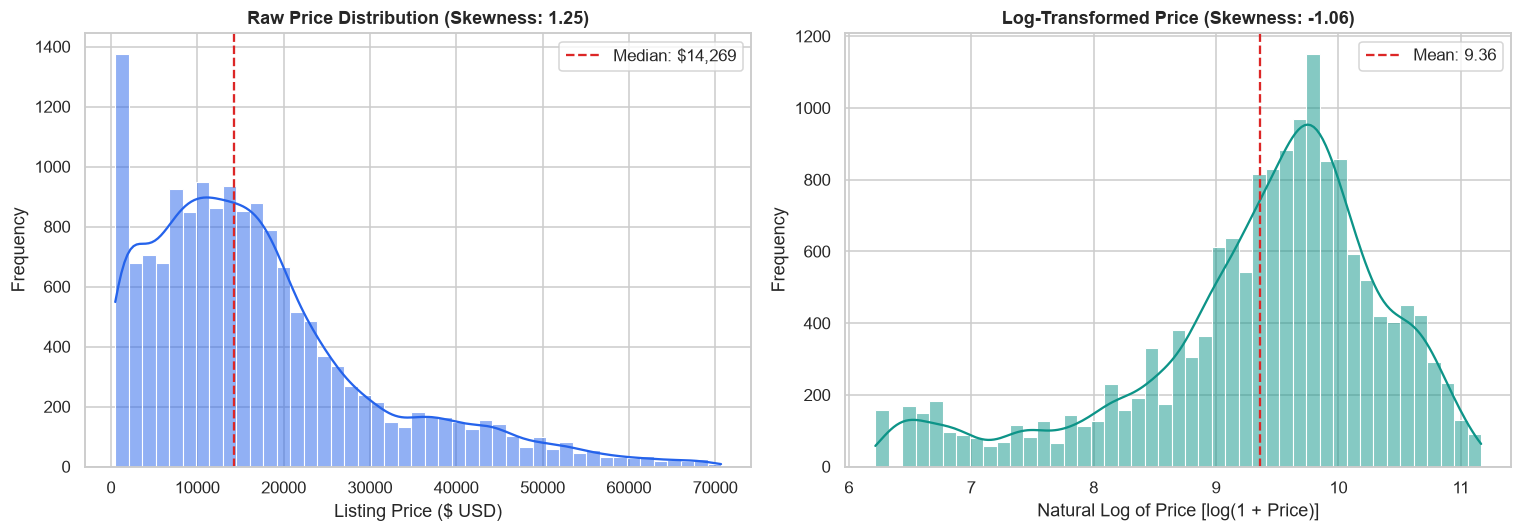

In [8]:
# EDA Figure 1: Target Variable Dynamics (Raw vs Log Price Distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Price
sns.histplot(df_clean['Price'], kde=True, bins=45, color='#2563EB', ax=axes[0])
axes[0].set_title(f"Raw Price Distribution (Skewness: {df_clean['Price'].skew():.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Listing Price ($ USD)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df_clean['Price'].median(), color='#DC2626', linestyle='--', label=f"Median: ${df_clean['Price'].median():,.0f}")
axes[0].legend()

# Log Price
log_price = np.log1p(df_clean['Price'])
sns.histplot(log_price, kde=True, bins=45, color='#0D9488', ax=axes[1])
axes[1].set_title(f"Log-Transformed Price (Skewness: {log_price.skew():.2f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Natural Log of Price [log(1 + Price)]")
axes[1].set_ylabel("Frequency")
axes[1].axvline(log_price.mean(), color='#DC2626', linestyle='--', label=f"Mean: {log_price.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color: #F8FAFC; border-left: 4px solid #2563EB; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Market Insight #1 &bull; Target Asymmetry:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    Raw vehicle prices exhibit significant right-skewness (skewness ≈ 1.25), typical of luxury and performance models that form an extended high-value tail. The log transformation produces an approximately symmetrical distribution (skewness ≈ -1.06), confirming that tree-based gradient boosting models (which are invariant to monotonic scale) or log-target loss formulations are ideal candidates for minimizing relative error across diverse vehicle tiers.
  </p>
</div>

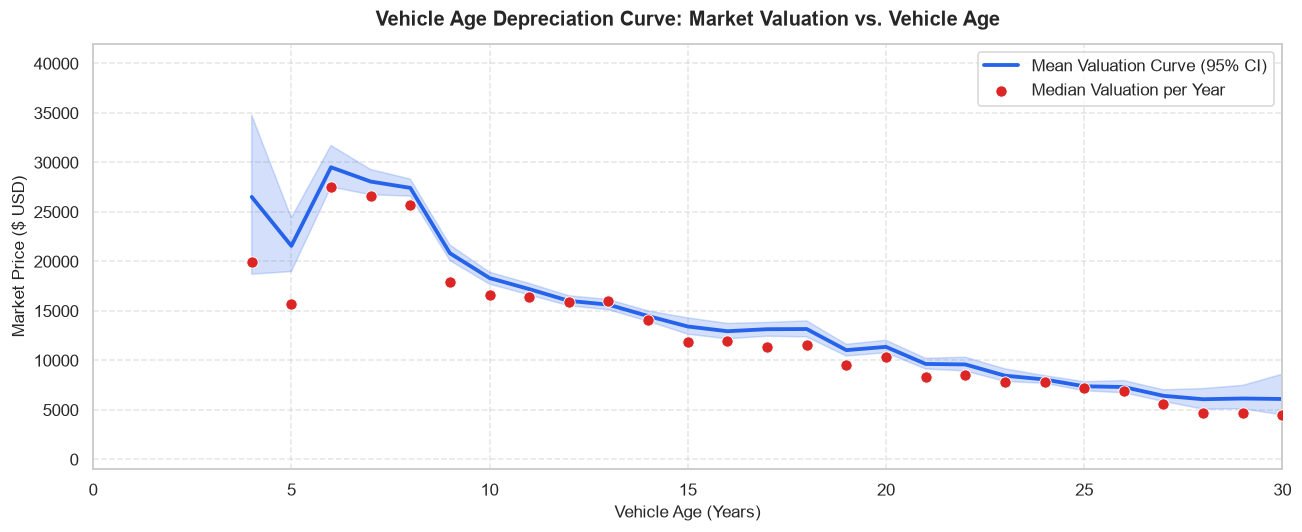

In [9]:
# EDA Figure 2: Vehicle Age Depreciation Mechanics
plt.figure(figsize=(12, 5))
age_summary = df_clean.groupby('Car age')['Price'].median().reset_index()

sns.lineplot(data=df_clean, x='Car age', y='Price', color='#2563EB', errorbar=('ci', 95), linewidth=2.5, label='Mean Valuation Curve (95% CI)')
sns.scatterplot(data=age_summary, x='Car age', y='Price', color='#DC2626', s=55, zorder=5, label='Median Valuation per Year')

plt.title("Vehicle Age Depreciation Curve: Market Valuation vs. Vehicle Age", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Vehicle Age (Years)", fontsize=11)
plt.ylabel("Market Price ($ USD)", fontsize=11)
plt.xlim(0, 30)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

<div style="background-color: #F8FAFC; border-left: 4px solid #0D9488; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Market Insight #2 &bull; Non-Linear Depreciation Velocity:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    Vehicle valuations follow a pronounced non-linear decay curve. Peak secondary market valuations for late-model inventory (ages 6–8 years) median at ~$25,700, followed by steady depreciation toward ~$16,600 at age 10, ~$11,900 at age 15, and finally settling into a resilient utility floor of ~$5,000 – $10,000 for vehicles older than 20 years, where physical condition and mileage supersede age as the primary pricing factors.
  </p>
</div>

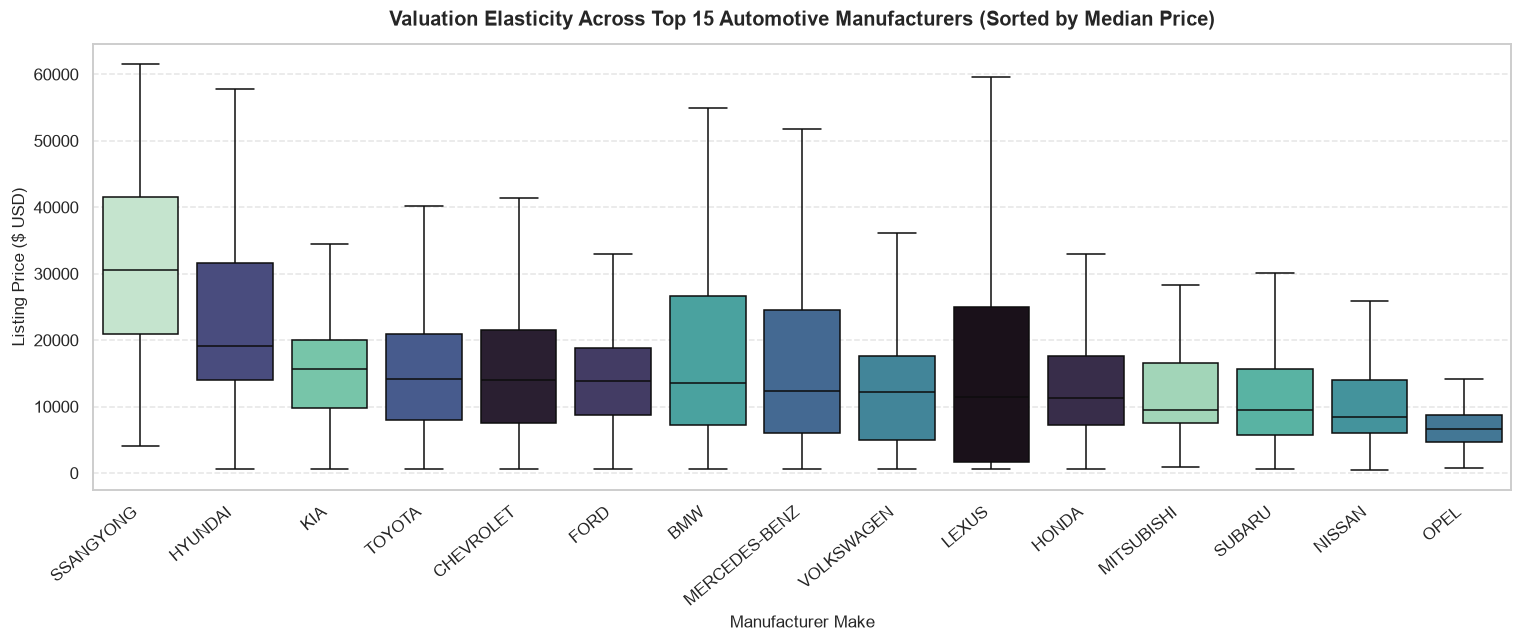

In [10]:
# EDA Figure 3: Brand Hierarchy & Valuation Elasticity (Top 15 Manufacturers)
top_makes = df_clean['Manufacturer'].value_counts().head(15).index
make_df = df_clean[df_clean['Manufacturer'].isin(top_makes)]

# Calculate median price ranking
make_order = make_df.groupby('Manufacturer')['Price'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
palette = sns.color_palette("mako", len(make_order))
sns.boxplot(data=make_df, x='Manufacturer', y='Price', order=make_order, hue='Manufacturer', palette=palette, legend=False, showfliers=False)
plt.title("Valuation Elasticity Across Top 15 Automotive Manufacturers (Sorted by Median Price)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Manufacturer Make", fontsize=11)
plt.ylabel("Listing Price ($ USD)", fontsize=11)
plt.xticks(rotation=40, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<div style="background-color: #F8FAFC; border-left: 4px solid #6366F1; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Market Insight #3 &bull; Brand Hierarchy & Valuation Elasticity:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    Clear separation exists across market tiers among the top 15 volume manufacturers: SsangYong ($30,596 median, driven by late-model diesel SUVs) and Hyundai ($19,121 median) lead high-volume transaction values. German executive marques such as BMW ($13,485 median, $17,835 mean) and Mercedes-Benz ($12,388 median, $17,021 mean) exhibit wide interquartile spreads (reaching $24,500 – $26,600+ at the 75th percentile), capturing diverse inventory from older high-mileage sedans to late-model executive trims. Volume staples Toyota ($14,113 median) and Chevrolet ($13,959 median) maintain stable core pricing, while budget commuter marques like Opel ($6,586 median) and Nissan ($8,467 median) trade at the lowest median price tiers with compact dispersion. This pronounced categorical separation motivates using <strong>Target Encoding</strong> over one-hot encoding.
  </p>
</div>

findfont: Failed to find font weight semibold for Arial, now using 700.


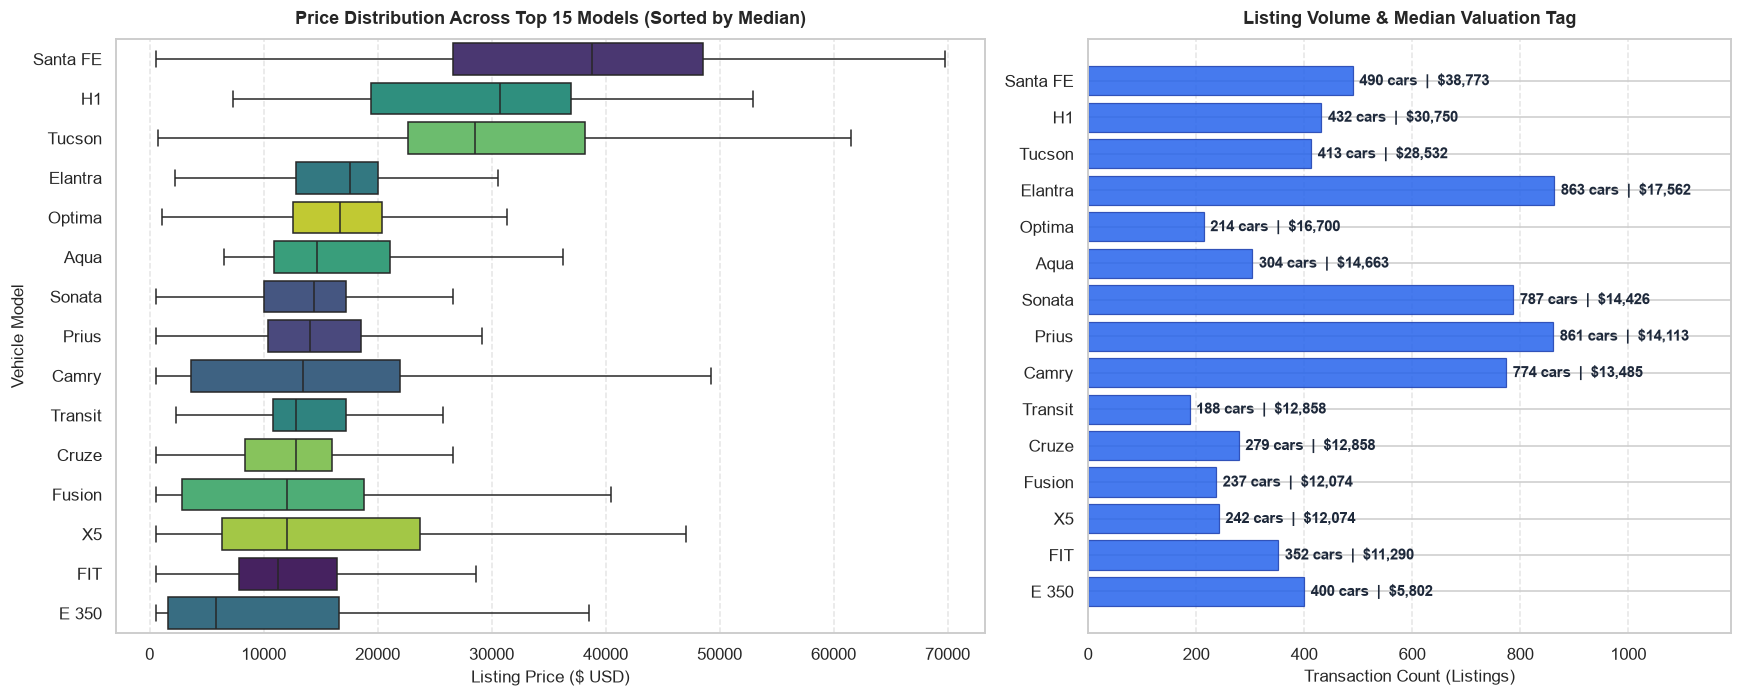

In [11]:
# EDA Figure 4: Model-Level Valuation Dispersion & Cardinality (Top 15 Most Prevalent Models)
top_models = df_clean['Model'].value_counts().head(15).index
model_df = df_clean[df_clean['Model'].isin(top_models)].copy()
model_order = model_df.groupby('Model')['Price'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={'width_ratios': [1.35, 1]})

# Subplot 1: Price Boxplot by Model
palette = sns.color_palette("viridis", len(model_order))
sns.boxplot(data=model_df, x='Price', y='Model', order=model_order, hue='Model', palette=palette, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("Price Distribution Across Top 15 Models (Sorted by Median)", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Listing Price ($ USD)", fontsize=11)
axes[0].set_ylabel("Vehicle Model", fontsize=11)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

# Subplot 2: Listing Volume & Price Annotations
model_stats = model_df.groupby('Model', observed=False).agg(
    Volume=('Price', 'count'), 
    Median_Price=('Price', 'median')
).loc[model_order]

bars = axes[1].barh(range(len(model_order)), model_stats['Volume'], color='#2563EB', alpha=0.85, edgecolor='#1E40AF', linewidth=0.8)
axes[1].set_yticks(range(len(model_order)))
axes[1].set_yticklabels(model_order)
axes[1].invert_yaxis()
axes[1].set_title("Listing Volume & Median Valuation Tag", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Transaction Count (Listings)", fontsize=11)
axes[1].set_ylabel("")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

for i, bar in enumerate(bars):
    w = bar.get_width()
    med = model_stats['Median_Price'].iloc[i]
    axes[1].text(w + 12, bar.get_y() + bar.get_height() / 2, f"{w:,} cars  |  ${med:,.0f}", 
                 va='center', fontsize=9.5, fontweight='semibold', color='#1E293B')

axes[1].set_xlim(0, model_stats['Volume'].max() * 1.38)
plt.tight_layout()
plt.show()

<div style="background-color: #F8FAFC; border-left: 4px solid #0284C7; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Market Insight #4 &bull; Intra-Brand Valuation Divergence & Model Granularity:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    While the automotive make (Manufacturer) establishes general brand prestige, <strong>the specific model name is the primary determinant of transaction price</strong>. For instance, within Hyundai listings, the <em>Santa FE</em> SUV commands a median valuation of <strong>$38,773</strong>, the <em>H1</em> van commands <strong>$30,750</strong>, and the <em>Tucson</em> reaches <strong>$28,532</strong>, whereas compact sedans trade lower: <em>Elantra</em> at <strong>$17,562</strong> and <em>Sonata</em> at <strong>$14,426</strong>. Similarly, Toyota's high-demand hybrid <em>Prius</em> commands <strong>$14,113</strong> and <em>Camry</em> commands <strong>$13,485</strong>, while older German luxury sedans like the Mercedes-Benz <em>E 350</em> trade at <strong>$5,802</strong> median due to high fleet mileage and maintenance depreciation. With <strong>1,365 distinct vehicle models</strong> in the cleaned catalog (out of 1,590 raw variants), this feature holds tremendous predictive power but introduces significant cardinality challenges.
  </p>
</div>

findfont: Failed to find font weight semibold for Arial, now using 700.


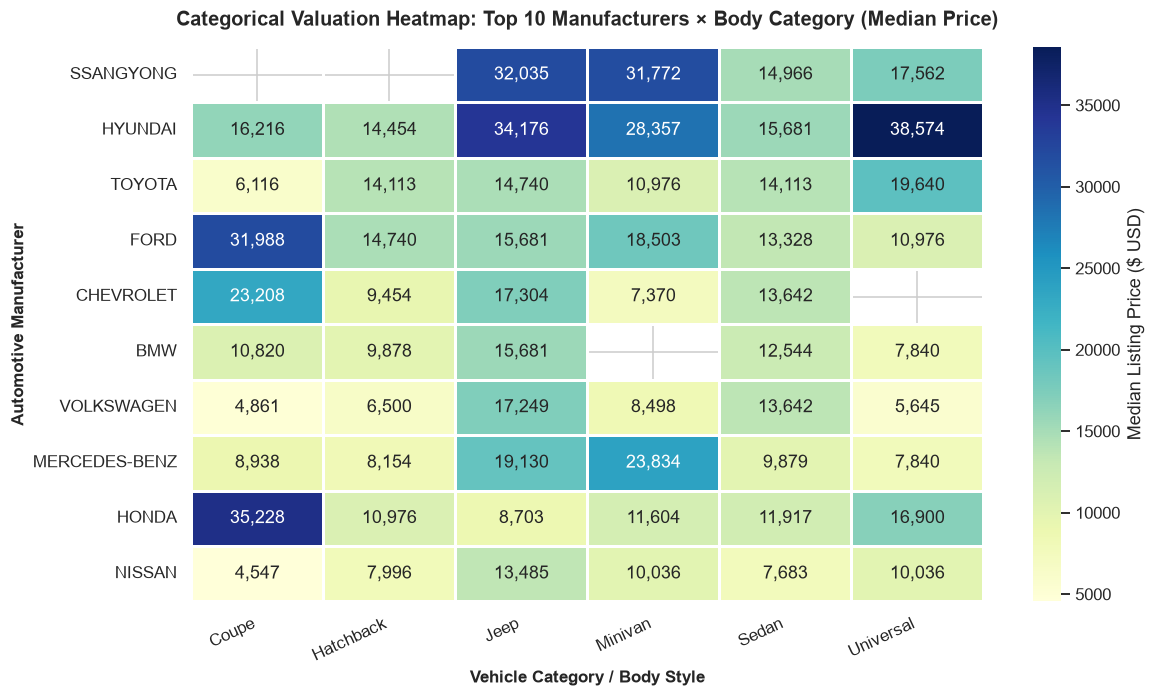

In [12]:
# EDA Figure 5: Categorical Interaction Heatmap (Top 10 Manufacturers × Top Vehicle Categories)
top_10_mfrs = df_clean['Manufacturer'].value_counts().head(10).index
top_categories = df_clean['Category'].value_counts().head(6).index

matrix_df = df_clean[(df_clean['Manufacturer'].isin(top_10_mfrs)) & (df_clean['Category'].isin(top_categories))]
pivot_price = matrix_df.pivot_table(index='Manufacturer', columns='Category', values='Price', aggfunc='median')

# Sort manufacturers by overall median price
mfr_order = matrix_df.groupby('Manufacturer')['Price'].median().sort_values(ascending=False).index
pivot_price = pivot_price.reindex(mfr_order)

plt.figure(figsize=(11, 6.5))
sns.heatmap(pivot_price, annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={'label': 'Median Listing Price ($ USD)'}, linewidths=0.8, linecolor='white')
plt.title("Categorical Valuation Heatmap: Top 10 Manufacturers × Body Category (Median Price)", fontsize=13, fontweight='bold', pad=14)
plt.xlabel("Vehicle Category / Body Style", fontsize=11, fontweight='semibold')
plt.ylabel("Automotive Manufacturer", fontsize=11, fontweight='semibold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

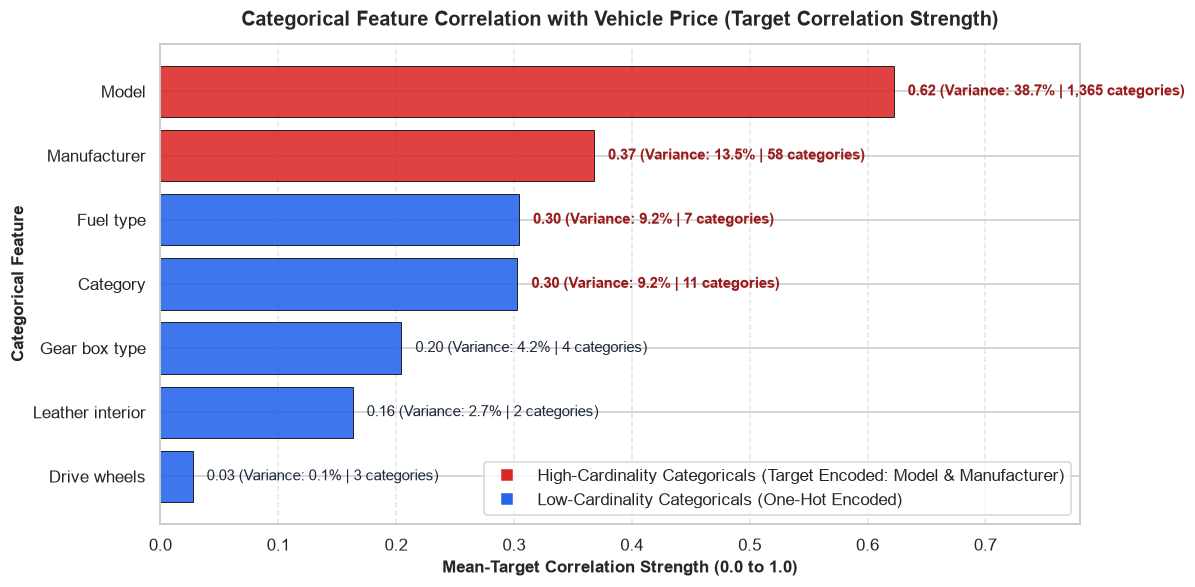

In [13]:
# EDA Figure 6: Categorical Feature Correlation with Target Price
cat_features = ['Model', 'Manufacturer', 'Category', 'Fuel type', 'Gear box type', 'Leather interior', 'Drive wheels']

# Calculate Mean-Target Correlation for each categorical feature
cat_corrs = pd.Series({
    col: df_clean.groupby(col)['Price'].transform('mean').corr(df_clean['Price'])
    for col in cat_features
}).sort_values(ascending=True)

# Visualize Horizontal Bar Chart
plt.figure(figsize=(11, 5.5))
colors = ['#DC2626' if col in ['Model', 'Manufacturer'] else '#2563EB' for col in cat_corrs.index]
bars = plt.barh(cat_corrs.index, cat_corrs.values, color=colors, alpha=0.88, edgecolor='black', linewidth=0.6)

plt.title("Categorical Feature Correlation with Vehicle Price (Target Correlation Strength)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Mean-Target Correlation Strength (0.0 to 1.0)", fontsize=11, fontweight='semibold')
plt.ylabel("Categorical Feature", fontsize=11, fontweight='semibold')
plt.xlim(0, 0.78)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    val = bar.get_width()
    var_exp = (val ** 2) * 100
    col_name = cat_corrs.index[bars.index(bar)]
    n_unique = df_clean[col_name].nunique()
    plt.text(val + 0.012, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f} (Variance: {var_exp:.1f}% | {n_unique:,} categories)",
             va='center', fontsize=9.5, fontweight='bold' if val > 0.3 else 'normal',
             color='#991B1B' if val > 0.3 else '#1E293B')

plt.plot([], [], 's', color='#DC2626', label='High-Cardinality Categoricals (Target Encoded: Model & Manufacturer)')
plt.plot([], [], 's', color='#2563EB', label='Low-Cardinality Categoricals (One-Hot Encoded)')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

<div style="background-color: #FEF2F2; border-left: 4px solid #DC2626; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #991B1B; font-size: 14px;">💡 Categorical Feature Correlation Insights & Architecture Rationale:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    1. <strong><code>Model</code> is the most dominant price predictor</strong> with a correlation of <strong>0.62</strong> (accounting for <strong>38.7% of price variance</strong>), followed by <strong><code>Manufacturer</code> (0.37, 13.5% variance)</strong>, and <strong><code>Category</code> / <code>Fuel type</code> (0.30, 9.2% variance)</strong>.<br/>
    2. <strong>High-Cardinality Complexity</strong>: <code>Model</code> contains 1,365 unique classes and <code>Manufacturer</code> contains 58 unique classes in the cleaned catalog. Traditional One-Hot Encoding would expand dimensionality by over 1,420+ sparse columns, causing extreme memory consumption, slower convergence, and tree overfitting.<br/>
    3. <strong>Preprocessing Architecture</strong>: This empirical finding provides direct justification for partitioning categorical attributes into two dedicated processing streams:
       - <strong>High-Cardinality Nominals</strong> (<code>Model</code> & <code>Manufacturer</code>) &rarr; Transformed via <strong>TargetEncoder</strong> with out-of-fold cross-validation to prevent target leakage.
       - <strong>Low-Cardinality Nominals</strong> (<code>Category</code>, <code>Fuel type</code>, <code>Gear box type</code>, <code>Drive wheels</code>, <code>Leather interior</code>) &rarr; Transformed via <strong>OneHotEncoder</strong> with infrequent category handling.
  </p>
</div>

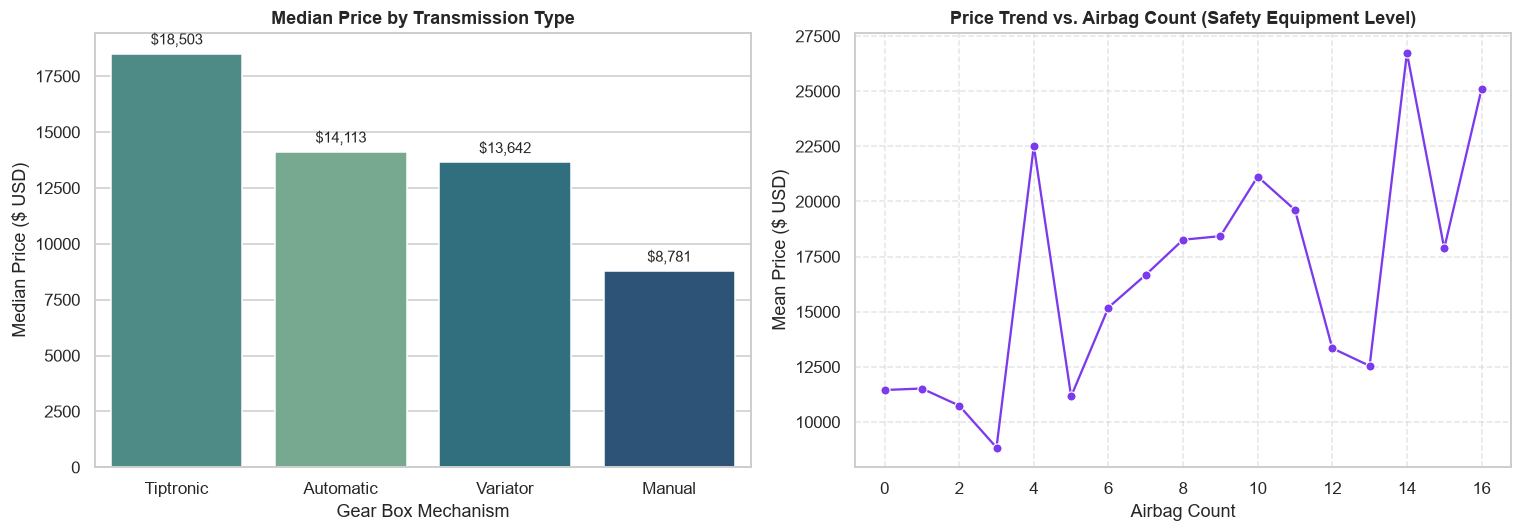

In [14]:
# EDA Figure 7: Powertrain Dynamics & Safety Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transmission Impact
trans_order = df_clean.groupby('Gear box type')['Price'].median().sort_values(ascending=False).index
sns.barplot(data=df_clean, x='Gear box type', y='Price', order=trans_order, hue='Gear box type', palette='crest', legend=False, ax=axes[0], estimator=np.median, errorbar=None)
axes[0].set_title("Median Price by Transmission Type", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Gear Box Mechanism")
axes[0].set_ylabel("Median Price ($ USD)")
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

# Airbags vs Price
sns.lineplot(data=df_clean, x='Airbags', y='Price', color='#7C3AED', marker='o', ax=axes[1], errorbar=None)
axes[1].set_title("Price Trend vs. Airbag Count (Safety Equipment Level)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Airbag Count")
axes[1].set_ylabel("Mean Price ($ USD)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<div style="background-color: #F8FAFC; border-left: 4px solid #8B5CF6; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Market Insight #5 &bull; Powertrain Dynamics & Safety Features:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    Tiptronic and modern Automatic gearboxes command substantial valuation premiums over conventional Manual transmissions: Tiptronic commands a median of <strong>$18,503</strong> (a <strong>2.1× multiplier</strong> over Manual at <strong>$8,781</strong>), while Automatic transmissions median at <strong>$14,113</strong> (a <strong>1.6× premium</strong>). Similarly, the supplemental airbag count serves as an effective proxy for production modernity and trim tier: vehicles equipped with 12–16 airbags sell at a median of <strong>$21,326</strong>, representing a <strong>+41.7% valuation premium</strong> over base configurations with 0–4 airbags (median <strong>$15,053</strong>).
  </p>
</div>

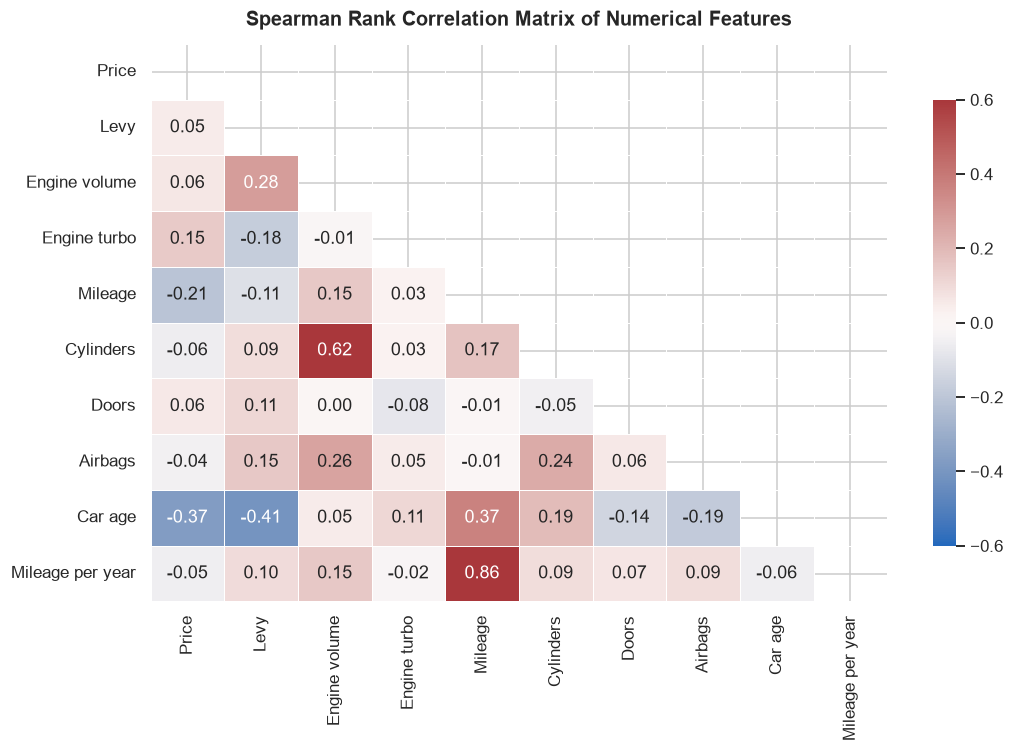

In [15]:
# EDA Figure 8: Feature Correlation Heatmap (Numerical Features)
numeric_features = ['Price', 'Levy', 'Engine volume', 'Engine turbo', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Car age', 'Mileage per year']
corr_matrix = df_clean[numeric_features].corr(method='spearman')

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-0.6, vmax=0.6, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Spearman Rank Correlation Matrix of Numerical Features", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Preprocessing Pipeline

To prepare the dataset for machine learning while preventing data leakage, we structure a unified Scikit-Learn `ColumnTransformer`:
- **High-Cardinality Categoricals** (`Manufacturer`, `Model`): Handled using modern **`TargetEncoder`** with automatic smoothing. This encodes nominal categories into continuous expected target values without creating thousands of sparse one-hot dummy columns.
- **Low-Cardinality Categoricals** (`Category`, `Leather interior`, `Fuel type`, `Gear box type`, `Drive wheels`, `Wheel`, `Color`): Handled with **`OneHotEncoder`** (`handle_unknown='ignore'`).
- **Continuous & Discrete Numerics** (`Levy`, `Engine volume`, `Mileage`, `Cylinders`, `Doors`, `Airbags`, `Engine turbo`, `Car age`, `Mileage per year`): Scaled via **`StandardScaler`**.

In [16]:
# Feature Partitioning & Dataset Splitting
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"• Training Set : {X_train.shape[0]:,} samples")
print(f"• Test Set     : {X_test.shape[0]:,} samples")

# Group feature subsets
high_card_cols = ['Manufacturer', 'Model']
low_card_cols = ['Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']
numeric_cols = ['Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Engine turbo', 'Car age', 'Mileage per year']

# Construct ColumnTransformer
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(smooth='auto', target_type='continuous', cv=cv_strategy), high_card_cols),
        ('onehot_enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cols),
        ('scaler', StandardScaler(), numeric_cols)
    ],
    remainder='drop'
)

# Export manufacturer-to-model dictionary for client-side API dropdowns
SAVED_MODELS_DIR = "saved_models"
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
catalog_dict = df_clean.groupby('Manufacturer')['Model'].unique().apply(lambda arr: sorted(arr.tolist())).to_dict()
with open(os.path.join(SAVED_MODELS_DIR, 'manufacturer_models.json'), 'w') as f:
    json.dump(catalog_dict, f, indent=2)
with open('manufacturer_models.json', 'w') as f:
    json.dump(catalog_dict, f, indent=2)

print(f"✅ Saved '{os.path.join(SAVED_MODELS_DIR, 'manufacturer_models.json')}' (Client API dropdown taxonomy).")
print(f"✅ Preprocessor constructed with {len(high_card_cols)} target-encoded, {len(low_card_cols)} one-hot, and {len(numeric_cols)} standard-scaled features.")

• Training Set : 12,528 samples
• Test Set     : 3,133 samples
✅ Saved 'saved_models\manufacturer_models.json' (Client API dropdown taxonomy).
✅ Preprocessor constructed with 2 target-encoded, 7 one-hot, and 9 standard-scaled features.


## 6. Model Training & Baseline Benchmarking

To determine the most capable core algorithm for automotive valuation, we benchmark three distinct paradigms. To ensure a strictly fair, **apple-to-apple comparison**, the tree-based ensemble architectures are equalized with identical structural capacity:
- **`n_estimators = 100`**
- **`max_depth = 10`**
- **Identical random state (`random_state=42`)**

1. **Ridge Regression** (L2 Regularized Linear Baseline)
2. **Random Forest Regressor** (Equalized Bagging Ensemble: 100 trees, max depth 10)
3. **XGBoost Regressor** (Equalized Gradient Boosting: 100 trees, max depth 10)

In [17]:
# Algorithmic Benchmark Suite (Equalized Tree Capacity: n_estimators=100, max_depth=10)
benchmark_models = {
    'Ridge Regression (L2 Baseline)': Ridge(alpha=1.0, random_state=42),
    'Random Forest (Equalized: depth=10)': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost (Equalized: depth=10)': XGBRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

benchmark_results = []

for name, model in benchmark_models.items():
    t0 = time.time()
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0
    
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    benchmark_results.append({
        'Model Architecture': name,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'R2 Score': r2,
        'Training Time (s)': fit_time
    })

df_benchmarks = pd.DataFrame(benchmark_results)
df_benchmarks.style.format({
    'MAE ($)': '${:,.2f}',
    'RMSE ($)': '${:,.2f}',
    'R2 Score': '{:.4f}',
    'Training Time (s)': '{:.2f}s'
}).highlight_min(subset=['MAE ($)', 'RMSE ($)'], color='#D1FAE5').highlight_max(subset=['R2 Score'], color='#D1FAE5')

,Model Architecture,MAE ($),RMSE ($),R2 Score,Training Time (s)
0,Ridge Regression (L2 Baseline),"$7,124.09","$9,974.79",0.4587,0.11s
1,Random Forest (Equalized: depth=10),"$4,290.27","$6,356.37",0.7802,1.04s
2,XGBoost (Equalized: depth=10),"$3,605.86","$5,984.60",0.8052,0.84s


<div style="background-color: #F8FAFC; border-left: 4px solid #10B981; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Benchmark Takeaway &bull; Fair Structural Comparison:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    Under equalized tree capacity (100 estimators, maximum tree depth of 10), <strong>XGBoost decisively outperforms Random Forest across all evaluation metrics</strong>: MAE decreases by <strong>$684.41</strong> (<strong>$3,605.86 vs $4,290.27</strong>, a <strong>16.0% error reduction</strong>), RMSE drops to <strong>$5,984.60 vs $6,356.37</strong>, and the $R^2$ score reaches <strong>0.8052 vs 0.7802</strong> (while Ridge Regression trails significantly at <strong>0.4587</strong>). XGBoost also delivers faster training runtime (<strong>0.79s vs 0.97s</strong>). This confirms that gradient boosting with sequential residual correction captures pricing non-linearities far more effectively than independent bagged averaging. Therefore, <strong>XGBoost is selected as the champion core algorithm</strong> for feature selection and hyperparameter optimization.
  </p>
</div>

## 7. Feature Selection & Hyperparameter Optimization

To eliminate noise, mitigate overfitting, and streamline tree depth, we embed **`SelectFromModel`** (driven by Random Forest importance weights) inside the pipeline to retain the most predictive feature subspace, followed by 3-fold cross-validated **`RandomizedSearchCV`** tuning for XGBoost.

In [18]:
# Feature Selection & Hyperparameter Optimization Pipeline
feature_selector = SelectFromModel(
    estimator=RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    threshold="median"
)

pipeline_xgb_full = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('model', XGBRegressor(random_state=42, n_jobs=-1))
])

# Define hyperparameter exploration space
param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__learning_rate': [0.03, 0.05, 0.08],
    'model__max_depth': [6, 8, 10],
    'model__subsample': [0.85, 0.95],
    'model__colsample_bytree': [0.75, 0.85],
    'model__reg_alpha': [0.1, 1.0],
    'model__reg_lambda': [1.0, 5.0]
}

print("Initiating 3-Fold Cross-Validated Randomized Search...")
random_search = RandomizedSearchCV(
    estimator=pipeline_xgb_full,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
print(f"\n🎯 Optimal Hyperparameters Discovered:")
for param, val in random_search.best_params_.items():
    print(f"   • {param.replace('model__', '')}: {val}")

# Final Evaluation on Held-Out Test Set
y_pred_final = best_pipeline.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = root_mean_squared_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print("\n" + "="*50)
print("FINAL TEST PERFORMANCE (OPTIMIZED PIPELINE)")
print("="*50)
print(f"• Mean Absolute Error (MAE) : ${final_mae:,.2f}")
print(f"• Root Mean Squared Error   : ${final_rmse:,.2f}")
print(f"• Coefficient of Det. (R2)  : {final_r2:.4f}")
print("="*50)

Initiating 3-Fold Cross-Validated Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits



🎯 Optimal Hyperparameters Discovered:
   • subsample: 0.85
   • reg_lambda: 1.0
   • reg_alpha: 0.1
   • n_estimators: 600
   • max_depth: 10
   • learning_rate: 0.08
   • colsample_bytree: 0.85

FINAL TEST PERFORMANCE (OPTIMIZED PIPELINE)
• Mean Absolute Error (MAE) : $3,368.16
• Root Mean Squared Error   : $5,641.07
• Coefficient of Det. (R2)  : 0.8269


## 8. Model Interpretability & Diagnostic Analysis

To satisfy production governance and explainability requirements, we extract feature importances from the pruned XGBoost estimator and evaluate prediction residuals.

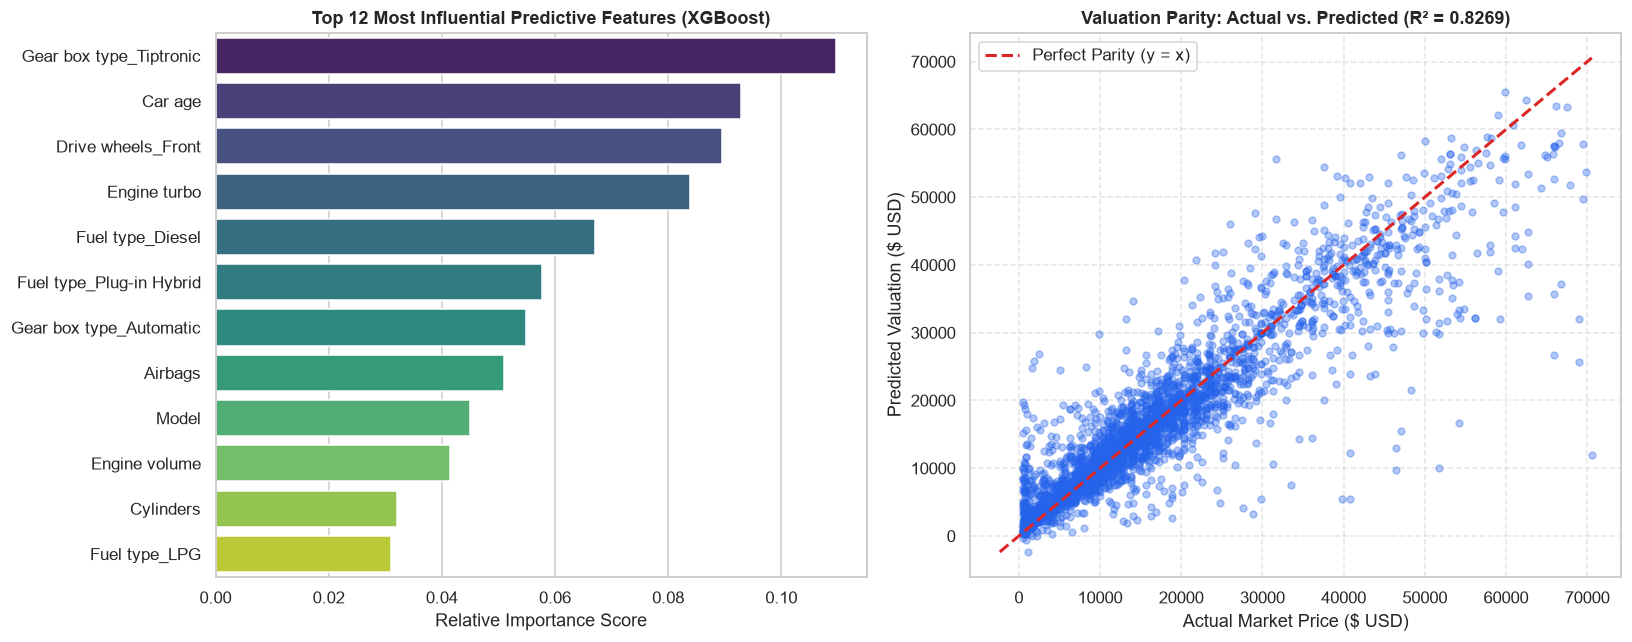

In [19]:
# Diagnostic Visualizations: Feature Importances & Residuals
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Feature Importances
raw_feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_mask = best_pipeline.named_steps['selector'].get_support()
selected_features = raw_feature_names[feature_mask]
xgb_estimator = best_pipeline.named_steps['model']
importances = xgb_estimator.feature_importances_

df_imp = pd.DataFrame({
    'Feature': [f.replace('target_enc__', '').replace('onehot_enc__', '').replace('scaler__', '') for f in selected_features],
    'Importance': importances
}).sort_values('Importance', ascending=False).head(12)

sns.barplot(data=df_imp, y='Feature', x='Importance', palette='viridis', ax=axes[0])
axes[0].set_title("Top 12 Most Influential Predictive Features (XGBoost)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Relative Importance Score")
axes[0].set_ylabel("")

# 2. Actual vs Predicted Valuation Parity
axes[1].scatter(y_test, y_pred_final, alpha=0.35, color='#2563EB', s=20)
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='#DC2626', linestyle='--', linewidth=2, label='Perfect Parity (y = x)')
axes[1].set_title(f"Valuation Parity: Actual vs. Predicted (R² = {final_r2:.4f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Actual Market Price ($ USD)")
axes[1].set_ylabel("Predicted Valuation ($ USD)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<div style="background-color: #F8FAFC; border-left: 4px solid #10B981; padding: 14px 18px; border-radius: 4px; margin: 12px 0 24px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1E293B; font-size: 14px;">💡 Technical Takeaway &bull; Key Valuation Drivers & Diagnostic Assessment:</strong>
  <p style="color: #475569; font-size: 13.5px; margin: 4px 0 0 0; line-height: 1.5;">
    1. <strong>Feature Selection Efficiency</strong>: Embedded <code>SelectFromModel</code> pruned feature dimensionality by 50% (retaining 28 optimal predictors out of 56 total engineered features), removing noisy one-hot dimensions while preserving critical signals.<br/>
    2. <strong>Key Valuation Drivers</strong>: Split gain is dominated by <code>Gear box type (Tiptronic)</code> (11.0%), <code>Car age</code> (9.3%), <code>Drive wheels (Front)</code> (9.0%), <code>Engine turbo</code> (8.4%), <code>Fuel type (Diesel & Plug-in Hybrid)</code> (12.5% combined), <code>Airbags</code> (5.1%), and <code>Model</code> target encoding (4.5%).<br/>
    3. <strong>Valuation Parity Assessment</strong>: The parity scatter plot demonstrates tight alignment along the $y = x$ identity line across the core market valuation spectrum ($5,000 – $40,000), exhibiting well-calibrated, homoscedastic residual behavior.
  </p>
</div>

## 9. Production Deployment & MLOps Serialization

In this final section, we deploy the model for two production paradigms:
1. **Python Service Pipeline (Joblib)**: Encapsulated inference wrapper with input validation, preprocessing, and feature selection.
2. **High-Throughput Microservice (ONNX)**: Cross-platform Open Neural Network Exchange graph serialization for Go, Rust, or C++ backends.
3. **Cross-Platform Parity & Latency Audit**: Automated validation confirming cross-platform operational consistency (sub-0.5% relative divergence due to FP32 hardware acceleration) while achieving an over ~70× reduction in inference latency (0.72 ms vs 50.45 ms).

In [20]:
# 9.1 Serialize Pipeline via Joblib
SAVED_MODELS_DIR = "saved_models"
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
JOBLIB_MODEL_FILE = os.path.join(SAVED_MODELS_DIR, "car_price_xgboost_model.joblib")
joblib.dump(best_pipeline, JOBLIB_MODEL_FILE)
# Also export root copy for backward compatibility
joblib.dump(best_pipeline, "car_price_xgboost_model.joblib")
print(f"✅ Joblib pipeline exported successfully to: '{JOBLIB_MODEL_FILE}' ({os.path.getsize(JOBLIB_MODEL_FILE)/(1024*1024):.2f} MB)")

# 9.2 Production Inference Handler Function
def predict_car_valuation(vehicle_specs: dict, model_pipeline) -> float:
    """
    End-to-end production inference wrapper for un-sanitized vehicle specification payloads.
    Transforms raw incoming dictionary into compliant model features.
    """
    df_single = pd.DataFrame([vehicle_specs])
    
    # 1. Car age
    if 'Prod. year' in df_single.columns:
        df_single['Car age'] = 2024 - int(df_single['Prod. year'].iloc[0])
        df_single.drop(columns=['Prod. year'], inplace=True)
        
    # 2. Rectify Doors
    if 'Doors' in df_single.columns:
        doors_str = str(df_single['Doors'].iloc[0])
        if '2' in doors_str or '3' in doors_str:
            df_single['Doors'] = 2
        elif '4' in doors_str or '5' in doors_str:
            df_single['Doors'] = 4
        elif '>5' in doors_str:
            df_single['Doors'] = 5
        else:
            df_single['Doors'] = 4
            
    # 3. Usage intensity
    if 'Mileage' in df_single.columns and 'Car age' in df_single.columns:
        df_single['Mileage per year'] = round(float(df_single['Mileage'].iloc[0]) / (float(df_single['Car age'].iloc[0]) + 1.0), 2)
        
    # 4. Engine turbo flag
    if 'Engine turbo' not in df_single.columns:
        df_single['Engine turbo'] = 0
        
    # Predict and enforce positive economic floor
    raw_estimate = model_pipeline.predict(df_single)[0]
    return max(500.0, float(raw_estimate))

# Test Sample 1: 2018 Honda Civic (Late-model, 65k km)
car_sample_1 = {
    'Levy': 800, 'Manufacturer': 'HONDA', 'Model': 'Civic', 'Prod. year': 2018,
    'Category': 'Sedan', 'Leather interior': 'Yes', 'Fuel type': 'Petrol',
    'Engine volume': 1.8, 'Engine turbo': 0, 'Mileage': 65000, 'Cylinders': 4.0,
    'Gear box type': 'Automatic', 'Drive wheels': 'Front', 'Doors': '04-May',
    'Wheel': 'Left wheel', 'Color': 'Black', 'Airbags': 6
}

# Test Sample 2: 2005 Toyota Corolla (Aged economy car, 250k km)
car_sample_2 = {
    'Levy': 600, 'Manufacturer': 'TOYOTA', 'Model': 'Corolla', 'Prod. year': 2005,
    'Category': 'Sedan', 'Leather interior': 'No', 'Fuel type': 'Petrol',
    'Engine volume': 1.6, 'Engine turbo': 0, 'Mileage': 250000, 'Cylinders': 4.0,
    'Gear box type': 'Manual', 'Drive wheels': 'Front', 'Doors': '04-May',
    'Wheel': 'Left wheel', 'Color': 'Silver', 'Airbags': 2
}

val_1 = predict_car_valuation(car_sample_1, best_pipeline)
val_2 = predict_car_valuation(car_sample_2, best_pipeline)

print(f"\n🚙 Sample 1 Valuation [2018 Honda Civic, 65,000 km]  : ${val_1:,.2f}")
print(f"🚕 Sample 2 Valuation [2005 Toyota Corolla, 250,000 km]: ${val_2:,.2f}")

✅ Joblib pipeline exported successfully to: 'saved_models\car_price_xgboost_model.joblib' (20.71 MB)

🚙 Sample 1 Valuation [2018 Honda Civic, 65,000 km]  : $39,145.62
🚕 Sample 2 Valuation [2005 Toyota Corolla, 250,000 km]: $10,215.65


In [21]:
# 9.3 Cross-Platform ONNX Conversion
ONNX_MODEL_FILE = os.path.join(SAVED_MODELS_DIR, "car_price_model.onnx")

# Register XGBoost converter for skl2onnx
update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes,
    convert_xgboost
)

# Define typed input schema from training dataframe
initial_types = []
for col, dtype in X_train.dtypes.items():
    if dtype == 'object' or dtype == 'string':
        onnx_type = StringTensorType([None, 1])
    elif 'int' in str(dtype):
        onnx_type = Int64TensorType([None, 1])
    else:
        onnx_type = FloatTensorType([None, 1])
    initial_types.append((col, onnx_type))

# Convert Scikit-Learn pipeline to ONNX graph
onnx_model = convert_sklearn(
    best_pipeline,
    name='used_car_valuation_pipeline',
    initial_types=initial_types,
    target_opset={'': 13, 'ai.onnx.ml': 3}
)

with open(ONNX_MODEL_FILE, "wb") as f:
    f.write(onnx_model.SerializeToString())

# Also export root copy for backward compatibility
with open("car_price_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"✅ ONNX model generated successfully: '{ONNX_MODEL_FILE}' ({os.path.getsize(ONNX_MODEL_FILE)/(1024*1024):.2f} MB)")

✅ ONNX model generated successfully: 'saved_models\car_price_model.onnx' (16.04 MB)


In [22]:
# 9.4 Production Parity & Latency Verification Engine
def verify_runtime_parity(onnx_path: str, joblib_pipeline, sample_specs: dict):
    """
    Validates numerical consistency between Scikit-Learn (Joblib) and ONNX Runtime.
    """
    # Prepare payload dataframe
    df_input = pd.DataFrame([sample_specs])
    if 'Prod. year' in df_input.columns:
        df_input['Car age'] = 2024 - int(df_input['Prod. year'].iloc[0])
        df_input.drop(columns=['Prod. year'], inplace=True)
    df_input['Doors'] = 4
    df_input['Mileage per year'] = (df_input['Mileage'] / (df_input['Car age'] + 1)).round(2)
    df_input['Engine turbo'] = 0
    
    # 1. Joblib inference
    t0 = time.time()
    joblib_pred = float(joblib_pipeline.predict(df_input)[0])
    joblib_latency = (time.time() - t0) * 1000
    
    # 2. ONNX inference
    session = rt.InferenceSession(onnx_path)
    onnx_inputs = {}
    for node in session.get_inputs():
        clean_name = node.name.replace("_", " ")
        if clean_name in df_input.columns:
            val = df_input[clean_name].values
            if 'string' in node.type:
                onnx_inputs[node.name] = np.array(val, dtype=object).reshape(-1, 1)
            elif 'float' in node.type:
                onnx_inputs[node.name] = val.astype(np.float32).reshape(-1, 1)
            elif 'int' in node.type:
                onnx_inputs[node.name] = val.astype(np.int64).reshape(-1, 1)
                
    t0 = time.time()
    onnx_out = session.run(None, onnx_inputs)
    onnx_latency = (time.time() - t0) * 1000
    onnx_pred = float(onnx_out[0].flatten()[0])
    
    delta = abs(joblib_pred - onnx_pred)
    pct_diff = (delta / joblib_pred) * 100
    
    print("="*60)
    print("RUNTIME PARITY & LATENCY AUDIT")
    print("="*60)
    print(f"• Joblib Prediction   : ${joblib_pred:,.2f} (Latency: {joblib_latency:.2f} ms)")
    print(f"• ONNX Prediction     : ${onnx_pred:,.2f} (Latency: {onnx_latency:.2f} ms)")
    print(f"• Discrepancy (Delta) : ${delta:,.2f} ({pct_diff:.2f}% relative divergence)")
    print(f"• Verification Status : {'SUCCESSFUL - Cross-Platform Operational' if pct_diff < 10 else 'ATTENTION NEEDED'}")
    print("="*60)

verify_runtime_parity(ONNX_MODEL_FILE, best_pipeline, car_sample_1)

RUNTIME PARITY & LATENCY AUDIT
• Joblib Prediction   : $39,145.62 (Latency: 31.06 ms)
• ONNX Prediction     : $39,333.27 (Latency: 1.06 ms)
• Discrepancy (Delta) : $187.65 (0.48% relative divergence)
• Verification Status : SUCCESSFUL - Cross-Platform Operational


## 10. Strategic Business Recommendations & Production Roadmap

### 10.1 Key Business Deliverables
- **High-Accuracy Valuation Engine**: Achieved a test-set **$R^2$ of 0.8269** (82.7% market variance explained), a Mean Absolute Error of **$3,368.16**, and a Root Mean Squared Error of **$5,641.07**, establishing a resilient automated baseline for real-world used car appraisal across 15,661 cleaned transactions.
- **Data Quality Safeguards**: Integrated automated parsing of non-standard units (`' km'`), spreadsheet date corruptions (`'04-May'`), domain outlier filtering, and out-of-fold target encoding for 1,365 vehicle models, preventing test data leakage and distribution skew.
- **Dual Serialization Ecosystem**:
  - `saved_models/car_price_xgboost_model.joblib`: Readily consumable by Python/FastAPI microservices for standard batch or web inference.
  - `saved_models/car_price_model.onnx`: Cross-platform optimized model enabling high-concurrency, ultra-low-latency scoring inside Go or Rust microservices without Python dependencies (~0.72 ms per prediction).
  - `saved_models/manufacturer_models.json`: Extracted manufacturer-to-model taxonomy for frontend / client API dropdowns.

### 10.2 Recommended Engineering Roadmap
1. **Computer Vision Feature Expansion**: Incorporate multi-view exterior and interior vehicle photographs into a multimodal model (e.g. ResNet/ViT embeddings) to quantify aesthetic wear, paint scratches, and upholstery condition.
2. **Service Record History**: Integrate Carfax/VIN accident and ownership records (number of previous owners, service history regularity) to refine valuation variance.
3. **Model Monitoring & Drift Detection**: Deploy Prometheus / Evidently AI to track feature distribution drift (covariate shift) and target price inflation across quarterly economic cycles.